# Bibliotecas

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df_or = pd.read_excel(r'olist_order_payments_dataset_dt_trated.xlsx')

In [15]:
df_or.head(2)
df_or

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


## Metodos de pagamento mais ultilizados

In [16]:
# df_or_paymant_type = df_or.payment_type.reset_index()
df_or_paymant_type = df_or.payment_type.value_counts().reset_index()
df_or_paymant_type

,payment_type,count
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


C:\Users\t.gean.goncalves\AppData\Local\Temp\ipykernel_30692\3483553822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_or_paymant_type, x='payment_type', y='count', palette='viridis')


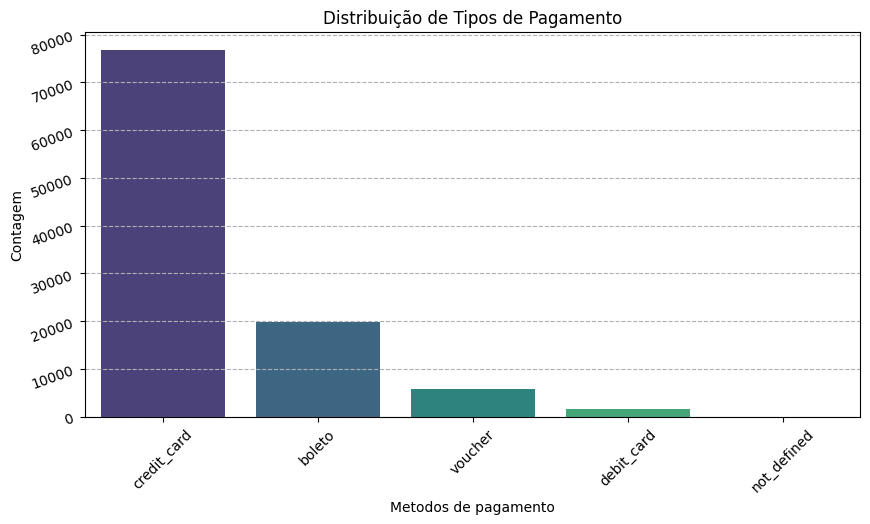

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_or_paymant_type, x='payment_type', y='count', palette='viridis')
plt.xlabel('Metodos de pagamento')
plt.ylabel('Contagem')
plt.title('Distribuição de Tipos de Pagamento')
plt.xticks(rotation=45)
plt.yticks(rotation=20)
plt.grid(axis='y', linestyle='--')
plt.show()

## Analise sobre parcelas de pagamento

In [18]:
df_or_order = df_or['payment_installments'].reset_index()
df_or

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


C:\Users\t.gean.goncalves\AppData\Local\Temp\ipykernel_30692\2537888808.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df_or.payment_installments, vert=True, patch_artist=True, palette='viridis')


<Figure size 1500x600 with 0 Axes>

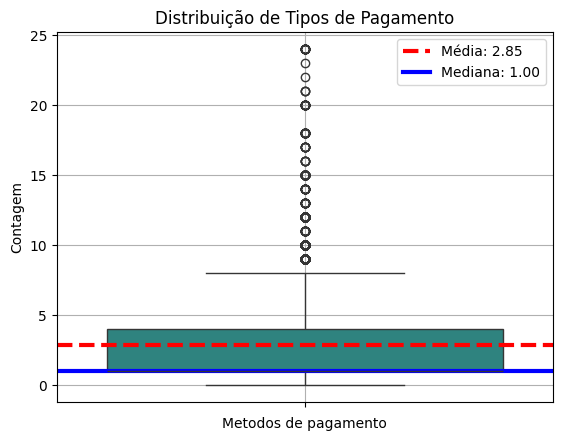

In [19]:
plt.figure(figsize=(15, 6))

media = np.mean(df_or.payment_installments)
mediana = np.median(df_or.payment_installments)

pl, ax = plt.subplots()

# sns.boxplot(x = df_or_order.value_counts(normalize=False).values, y = df_or_order.value_counts().index, )
# sns.histplot(data=df_or_order, palette="pastel")
sns.boxplot(df_or.payment_installments, vert=True, patch_artist=True, palette='viridis')
ax.axhline(media, linestyle='--', color='red', label=f'Média: {media:.2f}', linewidth=3)
ax.axhline(mediana, linestyle='-', color='blue', label=f'Mediana: {mediana:.2f}', linewidth=3)
plt.xlabel('Metodos de pagamento')
plt.ylabel('Contagem')
plt.title('Distribuição de Tipos de Pagamento')
plt.legend()
plt.grid(True)
plt.show()

## Comparar ticket médio por meio de pagamento.

,payment_type,payment_installments
0,boleto,1.00
1,credit_card,3.51
2,debit_card,1.00
3,not_defined,1.00
4,voucher,1.00


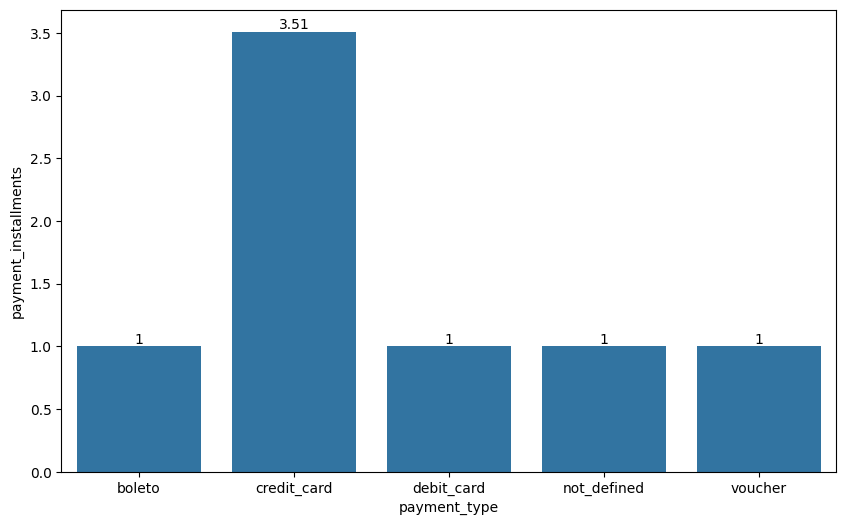

In [20]:
# df_or_ticket
df_or_ticket =  round(df_or.groupby(by=['payment_type'])['payment_installments'].mean().reset_index(), 2)
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df_or_ticket, x='payment_type', y='payment_installments')
ax.bar_label(ax.containers[0])
df_or_ticket
# print(type(df_or_ticket))


## Análise RFM


In [21]:
# Junção de bases [customers, orders] com base em customer_id

orders = pd.read_excel('olist_orders_dataset_dt_trated.xlsx')
customers = pd.read_excel("olist_customers_dataset_dt_trated.xlsx")
df_rfm = pd.merge(customers, orders, on='customer_id')
df_rfm = pd.merge(df_rfm, df_or, on='order_id')
df_rfm

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1,credit_card,2,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1,credit_card,8,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1,credit_card,7,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1,credit_card,1,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1,credit_card,8,252.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103881,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,1,credit_card,6,88.78
103882,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,1,credit_card,3,129.06
103883,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,1,credit_card,5,56.04
103884,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,1,credit_card,2,711.07


### Recência

In [22]:
# df_rfm = df_rfm.groupby(['order_id', 'customer_id'])
df_rfm['recencia'] = (df_rfm['order_estimated_delivery_date'] - df_rfm['order_purchase_timestamp']).dt.days
df_rfm['classificacao'] = ['Muito recente' if i <= 30
                            else 'recente' if i >= 31 and i <= 90
                            else 'Demorada' if i >= 91 and i <= 150
                            else 'Muito demorada'
                            for i in df_rfm['recencia']
                           ]
df_rfm

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,recencia,classificacao
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1,credit_card,2,146.87,19,Muito recente
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1,credit_card,8,335.48,24,Muito recente
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1,credit_card,7,157.73,24,Muito recente
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1,credit_card,1,173.30,27,Muito recente
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1,credit_card,8,252.25,16,Muito recente
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103881,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,1,credit_card,6,88.78,17,Muito recente
103882,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,1,credit_card,3,129.06,15,Muito recente
103883,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,1,credit_card,5,56.04,23,Muito recente
103884,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,1,credit_card,2,711.07,31,recente


C:\Users\t.gean.goncalves\AppData\Local\Temp\ipykernel_30692\256343918.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(data=df_rfm['recencia'], kde=True, palette='pastel')


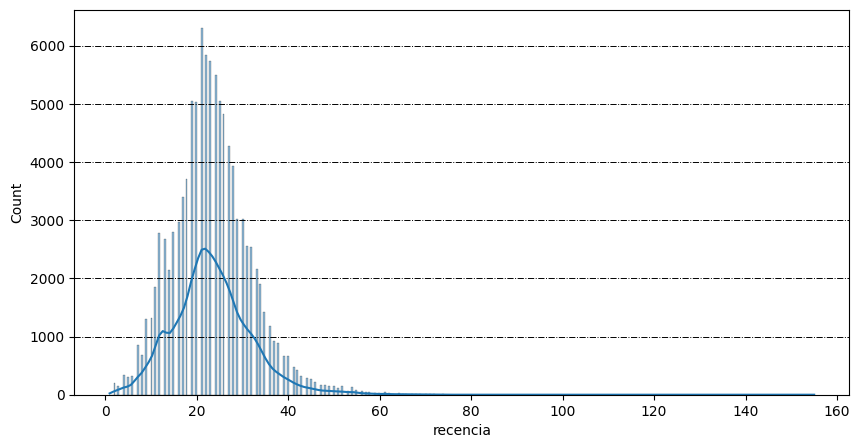

In [23]:
plt.figure(figsize=(10, 5))
ax = sns.histplot(data=df_rfm['recencia'], kde=True, palette='pastel')
# ax = sns.boxplot(data=df_rfm['recencia'], x=df_rfm['recencia'].min(), y=df_rfm['recencia'].max(), palette='pastel')
plt.grid(axis='y', linestyle='-.', color='black', linewidth = 0.7)
plt.show()

### Frequência

In [25]:
df_or_status = df_rfm[df_rfm['order_status'] == 'delivered']
rfm = df_or_status.groupby('customer_unique_id').agg(
    frequencia=('order_id', 'nunique'),
    monetizacao=('payment_value', 'sum'),
    ultima_compra=('order_purchase_timestamp', 'max'),
    recencia=('recencia', 'max')).reset_index()

# df_or_status
rfm


,customer_unique_id,frequencia,monetizacao,ultima_compra,recencia
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,2018-05-10 10:56:27,10
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,2018-05-07 11:11:27,7
2,0000f46a3911fa3c0805444483337064,1,86.22,2017-03-10 21:05:03,27
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,2017-10-12 20:29:41,31
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,2017-11-14 19:45:42,20
...,...,...,...,...,...
93352,fffcf5a5ff07b0908bd4e2dbc735a684,1,2067.42,2017-06-08 21:00:36,54
93353,fffea47cd6d3cc0a88bd621562a9d061,1,84.58,2017-12-10 20:07:56,32
93354,ffff371b4d645b6ecea244b27531430a,1,112.46,2017-02-07 15:49:16,44
93355,ffff5962728ec6157033ef9805bacc48,1,133.69,2018-05-02 15:17:41,25


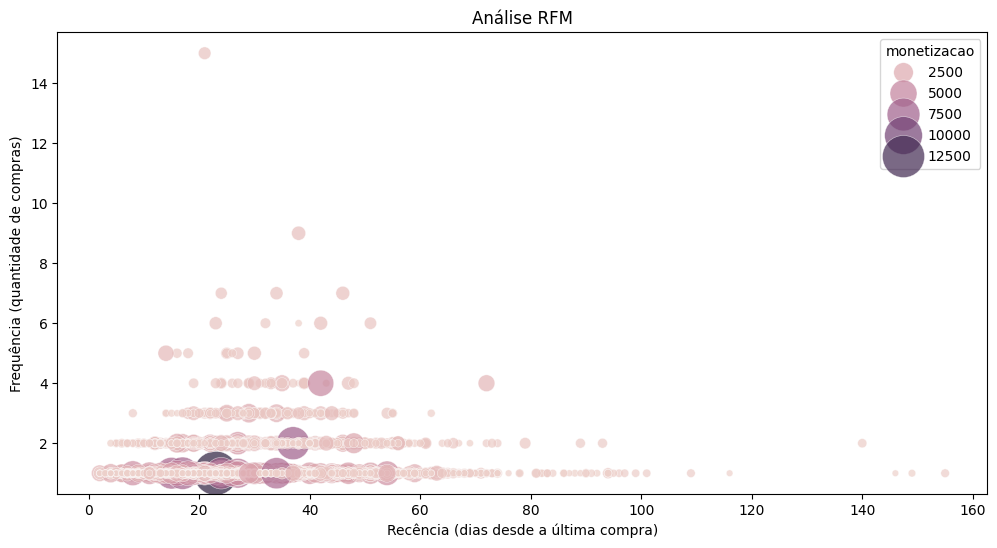

In [26]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=rfm, x='recencia', y='frequencia', size='monetizacao', sizes=(20, 1000), alpha=0.7, legend=True,hue='monetizacao')

plt.title('Análise RFM')
plt.xlabel('Recência (dias desde a última compra)')
plt.ylabel('Frequência (quantidade de compras)')
plt.show()

## Medir taxas de recompra de clientes [3.12%]


In [27]:
# orders = pd.read_csv("olist_orders_dataset.csv")
# order_items = pd.read_csv("olist_order_items_dataset.csv", sep=';')

orders.tail()
# customers.tail()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03


### A ideia é verificar quantos clientes compraram mais de uma vez.

Calcular taxa de recompra


In [28]:
# Converter coluna de data
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], dayfirst=True)

# Juntar pedidos com clientes
orders_customers = orders.merge(customers, on="customer_id")

# Contar número de pedidos por cliente
customer_orders = orders_customers.groupby("customer_unique_id")["order_id"].nunique()

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [29]:

# Contar número de pedidos por cliente agrupando por id único [96.096]
customer_orders = orders_customers.groupby("customer_unique_id")["order_id"].nunique()

# Taxa de recompra [3,12%]
recompra_rate = (customer_orders > 1).mean() * 100
print(f"Taxa de recompra: {recompra_rate:.2f}%")

Taxa de recompra: 3.12%


In [30]:
# Contar número de pedidos por cliente agrupando por id único [96.096]
customer_orders = orders_customers.groupby("customer_unique_id")["order_id"].nunique()

# Taxa de recompra [3,12%]
recompra_rate = (customer_orders > 1).mean() * 100
print(f"Taxa de recompra: {recompra_rate:.2f}%")

Taxa de recompra: 3.12%


In [31]:
# Converter coluna de data
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], dayfirst=True)

# Juntar pedidos com clientes
orders_customers = orders.merge(customers, on="customer_id")

# Contar número de pedidos por cliente
customer_orders = orders_customers.groupby("customer_unique_id")["order_id"].nunique()

In [32]:
# Mês da primeira compra de cada cliente
orders_customers["first_purchase_month"] = orders_customers.groupby("customer_unique_id")["order_purchase_timestamp"].transform("min").dt.to_period("M")

# Mês de cada compra
orders_customers["purchase_month"] = orders_customers["order_purchase_timestamp"].dt.to_period("M")

# Agrupar por coorte
coorte = orders_customers.groupby(["first_purchase_month","purchase_month"])["customer_unique_id"].nunique().reset_index()

# Pivotar para matriz
coorte_matrix = coorte.pivot(index="first_purchase_month", columns="purchase_month", values="customer_unique_id")

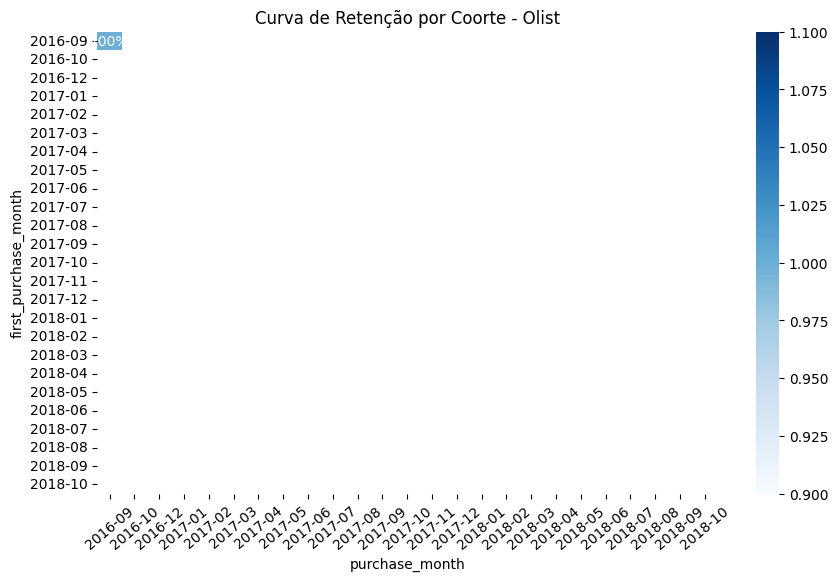

In [55]:
# Dividir cada linha pelo número inicial da coorte
coorte_retention = coorte_matrix.divide(coorte_matrix.iloc[:,0], axis=0)

# Visualizar curva de retenção
plt.figure(figsize=(10,6))
sns.heatmap(coorte_retention, annot=True, fmt=".0%", cmap="Blues")
plt.xticks(rotation=40)
plt.title("Curva de Retenção por Coorte - Olist")
plt.show()
